In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize



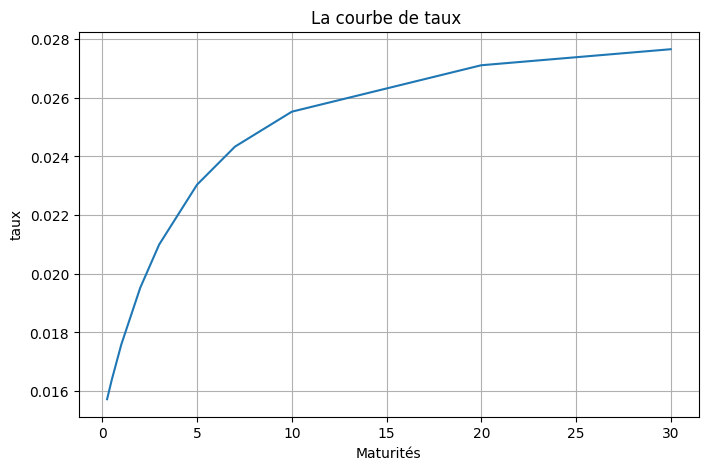

In [3]:
def taux_vasicek(maturites, a, b, sigma, r0):
    #convertir en tableau numpy
    maturites = np.array(maturites, dtype=float)
    
    # sécurité sur les paramètres
    if a <= 0 or sigma < 0:
        return np.full_like(maturites, np.nan, dtype=float)
    B = (1 - np.exp(-a * maturites)) / a
    A = np.exp(
        (b - sigma**2 / (2 * a**2)) * (B - maturites)
        - (sigma**2 / (4 * a)) * B**2
    )
    
    # prix du zéro-coupon
    P = A * np.exp(-B * r0)
    
    # éviter division par zéro
    eps = 1e-8
    
    # taux spot continu
    R = -np.log(P) / np.maximum(maturites, eps)
    
    return maturites,R
maturites = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
maurites,R=taux_vasicek(maturites, 0.4, 0.03, 0.02, 0.015)
plt.figure(figsize=(8,5))
plt.plot(maturites,R)
plt.title("La courbe de taux ")
plt.xlabel("Maturités")
plt.ylabel("taux")
plt.grid(True)